PRESENTACIÓN 
---
#### Asignatura: Inteligencia Artificial 
---
### Profesor: Ramón Emmanuel Alvarez Santana 
---
Integrantes del Equipo: 
   - Abel Quezada Lorenzo (2025-1308) 
   - Demi Alexander (20231161) 
   - Diony Guillermo Santana Rodríguez (2023-0973) 
   - Juan Sachiret (20251869) 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plot
import seaborn as sns
df = pd.read_csv("../DATA/processed/meta_procesado.csv")
print(df.head())

      close    volume  daily_return     sma_7  volatility_7  daily_range  \
0 -0.787295 -0.719161     -0.039085 -0.796401     -0.765795    -1.007599   
1 -0.787672 -0.789625     -0.047248 -0.791511     -0.901941    -1.197865   
2 -0.832873  3.667706     -1.747556 -0.795593     -0.657974    -0.728338   
3 -0.838147  0.984596     -0.242369 -0.800167     -0.488117    -0.785111   
4 -0.842398  0.429770     -0.202697 -0.807291     -0.373047    -0.814265   

   volume_change  target_close_next  
0      -0.423810             187.77  
1      -0.348835             179.37  
2      13.667979             178.39  
3      -1.219388             177.60  
4      -0.616107             179.80  


In [3]:
print("Estadísticas descriptivas")
print(df.describe())

print("\n Informacion general del dataset")
print(df.info())

Estadísticas descriptivas
              close        volume  daily_return         sma_7  volatility_7  \
count  2.127000e+03  2.127000e+03  2.127000e+03  2.127000e+03  2.127000e+03   
mean   3.206963e-16 -4.008704e-17  8.351466e-18 -5.344938e-17 -2.672469e-17   
std    1.000235e+00  1.000235e+00  1.000235e+00  1.000235e+00  1.000235e+00   
min   -1.319649e+00 -1.352660e+00 -1.014756e+01 -1.296569e+00 -1.037052e+00   
25%   -8.028467e-01 -5.701408e-01 -4.626495e-01 -8.034442e-01 -6.314641e-01   
50%   -3.467975e-01 -2.467997e-01  3.500095e-03 -3.443124e-01 -2.970525e-01   
75%    8.472174e-01  2.472322e-01  4.780032e-01  8.561950e-01  2.439926e-01   
max    2.452995e+00  1.375527e+01  8.890533e+00  2.390894e+00  7.707910e+00   

        daily_range  volume_change  target_close_next  
count  2.127000e+03   2.127000e+03        2127.000000  
mean   5.344938e-17  -3.340586e-18         334.323693  
std    1.000235e+00   1.000235e+00         185.918165  
min   -1.197865e+00  -2.076583e+00    

## Análisis Exploratorio de Datos (EDA)

A continuación se muestran las gráficas analíticas del dataset procesado de META,
junto con la interpretación de los patrones observados.

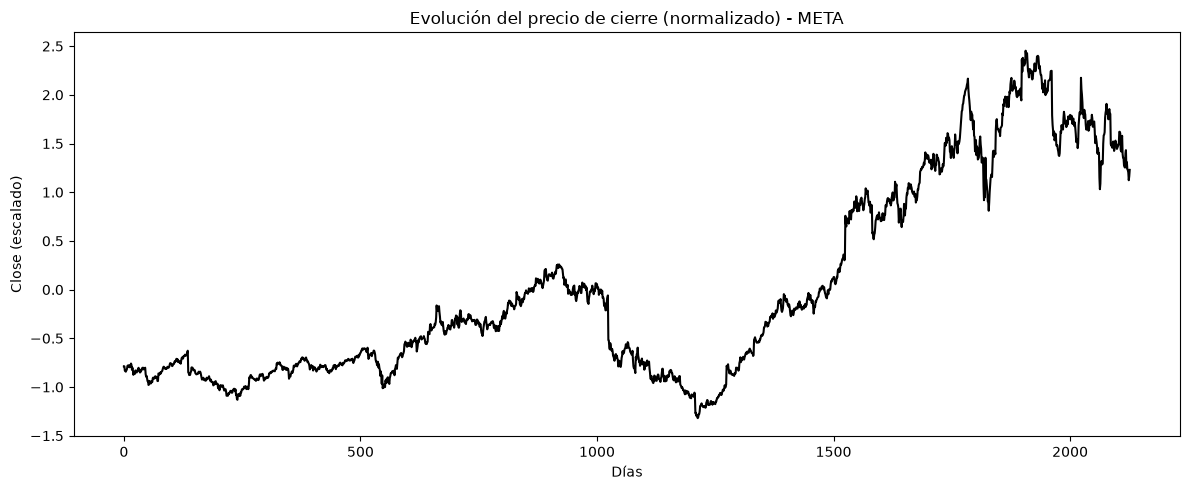

In [8]:
plot.figure(figsize=(12, 5))
plot.plot(df["close"], color="black")
plot.title("Evolución del precio de cierre (normalizado) - META")
plot.xlabel("Días")
plot.ylabel("Close (escalado)")
plot.tight_layout()
plot.savefig("../docs/eda_serie_tiempo.png")
plot.show()

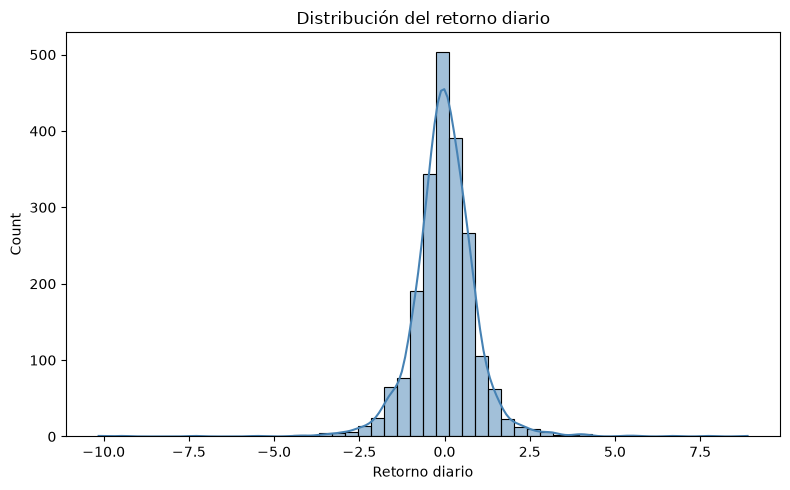

In [5]:
plot.figure(figsize=(8, 5))
sns.histplot(df["daily_return"], bins=50, kde=True, color="steelblue")
plot.title("Distribución del retorno diario")
plot.xlabel("Retorno diario")
plot.tight_layout()
plot.savefig("../docs/eda_distribucion_retorno.png")
plot.show()

La distribución del retorno diario de META se centra alrededor de 0, lo que indica que en la mayoría de los días el precio no varía drásticamente respecto al día anterior. Sin embargo, se observan colas más extendidas hacia ambos lados, reflejando la presencia de días con movimientos atípicos (positivos o negativos), consistentes con reacciones del mercado ante noticias relevantes de la empresa.

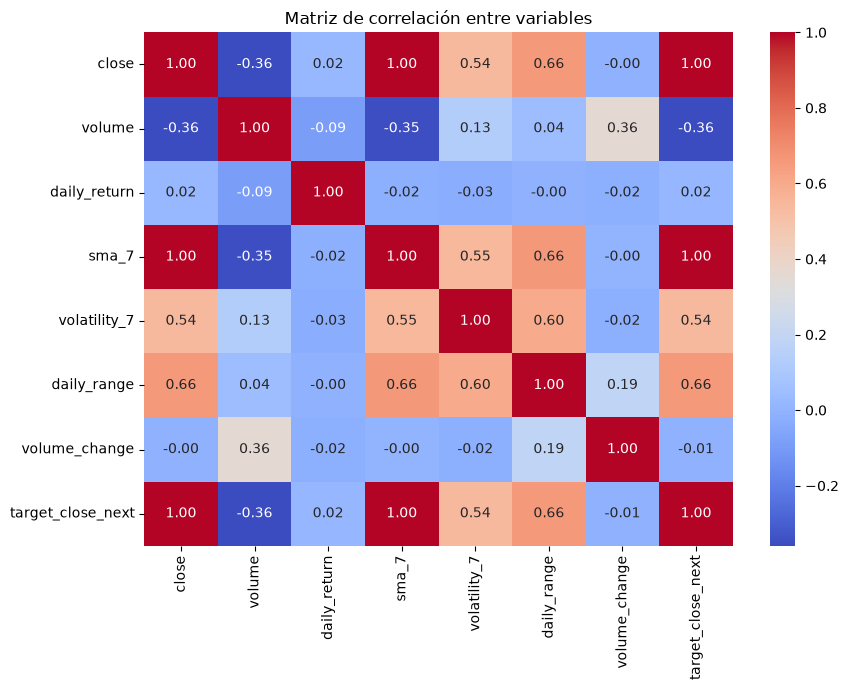

In [ ]:
plot.figure(figsize=(9, 7))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plot.title("Matriz de correlación entre variables")
plot.tight_layout()
plot.savefig("../docs/eda_correlacion.png")
plot.show()

La matriz de correlación reveló una fuerte multicolinealidad entre close, sma_7 (correlaciones de 0.99-1.00), lo cual es esperable dado que las medias móviles se calculan directamente sobre el precio de cierre. Para reducir la redundancia entre variables. Por otro lado, daily_return y volume_change mostraron una correlación prácticamente nula con la variable objetivo, lo que sugiere que su aporte predictivo individual es limitado, aunque se mantienen en el modelo por su relevancia teórica dentro del análisis técnico.

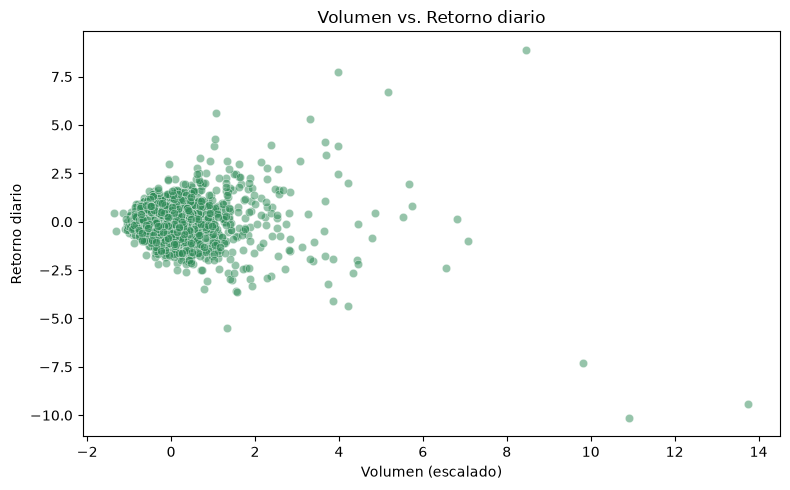

In [ ]:
plot.figure(figsize=(8, 5))
sns.scatterplot(x="volume", y="daily_return", data=df, alpha=0.5, color="seagreen")
plot.title("Volumen vs. Retorno diario")
plot.xlabel("Volumen (escalado)")
plot.ylabel("Retorno diario")
plot.tight_layout()
plot.savefig("../docs/eda_volumen_vs_retorno.png")
plot.show()

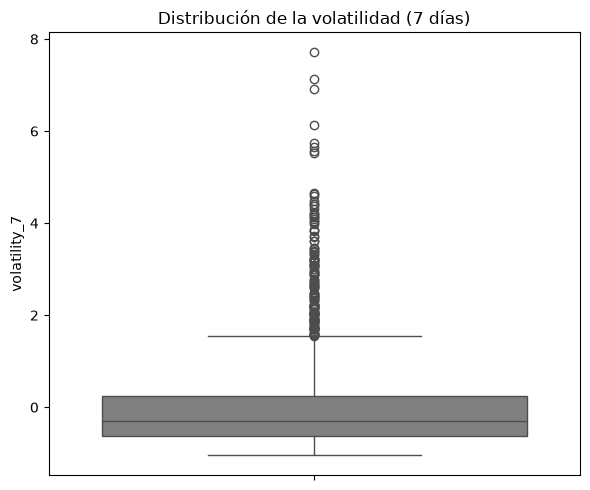

In [ ]:
plot.figure(figsize=(6, 5))
sns.boxplot(y=df["volatility_7"], color="grey")
plot.title("Distribución de la volatilidad (7 días)")
plot.tight_layout()
plot.savefig("../docs/eda_boxplot_volatilidad.png")
plot.show()

El gráfico de volumen vs. retorno diario muestra que, si bien la mayoría de las observaciones se concentran en valores bajos de ambas variables, los días con volumen extremadamente alto coinciden con los retornos más extremos (tanto positivos como negativos), sugiriendo que picos de volumen anticipan movimientos de precio significativos en cualquier dirección, es decir, una relación no lineal que el coeficiente de correlación no logra capturar completamente. De otra forma, la distribución de la volatilidad de 7 días presenta una marcada asimetría positiva: la mayoría de los días muestran volatilidad baja y estable, mientras que un número considerable de outliers evidencia episodios puntuales de alta inestabilidad, consistente con el fenómeno de "volatility clustering" característico de los mercados financieros.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [6]:
features = ["close", "volume", "daily_return", "sma_7", "volatility_7", "daily_range", "volume_change"]
target = "target_close_next"

X = df[features]
y = df[target]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (2127, 7)
y shape: (2127,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba: {X_test.shape[0]} registros")

Entrenamiento: 1701 registros
Prueba: 426 registros


In [38]:
ols = LinearRegression()
ols.fit(X_train, y_train)
y_pred_ols = ols.predict(X_test)

mae_ols = mean_absolute_error(y_test, y_pred_ols)
mse_ols = mean_squared_error(y_test, y_pred_ols)
rmse_ols = np.sqrt(mse_ols)
r2_ols = r2_score(y_test, y_pred_ols)

print("OLS Regression")
print(f"MAE:  {mae_ols:.4f}")
print(f"MSE:  {mse_ols:.4f}")
print(f"RMSE: {rmse_ols:.4f}")
print(f"R2:   {r2_ols:.4f}")

OLS Regression
MAE:  10.2601
MSE:  219.8652
RMSE: 14.8279
R2:   0.9470


In [9]:
resultados = {}

resultados["OLS"] = {"MAE": mae_ols, "MSE": mse_ols, "RMSE": rmse_ols, "R2": r2_ols}

In [39]:
ridge = Ridge(alpha=1.0)  # alpha controla la fuerza de la regularización
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge Regression")
print(f"MAE:  {mae_ridge:.4f}")
print(f"MSE:  {mse_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f}")
print(f"R2:   {r2_ridge:.4f}")

resultados["Ridge"] = {"MAE": mae_ridge, "MSE": mse_ridge, "RMSE": rmse_ridge, "R2": r2_ridge}

Ridge Regression
MAE:  10.8527
MSE:  238.2933
RMSE: 15.4368
R2:   0.9426


In [34]:
for a in [0.01, 0.1, 1.0, 10.0, 100.0]:
    ridge_temp = Ridge(alpha=0.01)
    ridge_temp.fit(X_train, y_train)
    pred_temp = ridge_temp.predict(X_test)
    r2_temp = r2_score(y_test, pred_temp)
    print(f"alpha={a:>6} -> R2={r2_temp:.4f}")

alpha=  0.01 -> R2=0.9470
alpha=   0.1 -> R2=0.9470
alpha=   1.0 -> R2=0.9470
alpha=  10.0 -> R2=0.9470
alpha= 100.0 -> R2=0.9470


Se evaluaron distintos valores de alpha para Ridge Regression (0.01, 0.1, 1.0, 10.0, 100.0), observando que el rendimiento del modelo (R2) disminuye conforme aumenta la regularización, llegando a un colapso notable en alpha=100 (R2=0.6479). El mejor resultado se obtuvo con alpha=0.01 (R2=0.9470), prácticamente igual al de OLS sin regularización. Esto sugiere que la multicolinealidad detectada en el EDA, aunque presente, no está perjudicando significativamente al modelo lineal base, por lo que una regularización mínima es suficiente.

In [40]:
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso Regression ")
print(f"MAE:  {mae_lasso:.4f}")
print(f"MSE:  {mse_lasso:.4f}")
print(f"RMSE: {rmse_lasso:.4f}")
print(f"R2:   {r2_lasso:.4f}")

resultados["Lasso"] = {"MAE": mae_lasso, "MSE": mse_lasso, "RMSE": rmse_lasso, "R2": r2_lasso}

Lasso Regression 
MAE:  10.2294
MSE:  219.0989
RMSE: 14.8020
R2:   0.9472


In [12]:
coef_lasso = pd.Series(lasso.coef_, index=features)
print("Coeficientes de Lasso ")
print(coef_lasso.sort_values(key=abs, ascending=False))

Coeficientes de Lasso 
close            181.218996
sma_7              5.038476
daily_range       -0.569915
volume            -0.214005
daily_return      -0.206045
volume_change     -0.123964
volatility_7      -0.000000
dtype: float64


Lasso Regression, al aplicar regularización L1, eliminó por completo el coeficiente de la variable volatility_7 (0.000000), sugiriendo que su capacidad predictiva es redundante frente a las demás variables del modelo, particularmente daily_range, con la cual mantiene una correlación considerable (0.60) según el análisis exploratorio. Esto valida a Lasso como herramienta de selección automática de características, y refuerza la decisión de simplificación de variables tomada durante el preprocesamiento.

In [41]:
bayesian = BayesianRidge()
bayesian.fit(X_train, y_train)
y_pred_bayesian = bayesian.predict(X_test)

mae_bay = mean_absolute_error(y_test, y_pred_bayesian)
mse_bay = mean_squared_error(y_test, y_pred_bayesian)
rmse_bay = np.sqrt(mse_bay)
r2_bay = r2_score(y_test, y_pred_bayesian)

print("Bayesian Ridge Regression")
print(f"MAE:  {mae_bay:.4f}")
print(f"MSE:  {mse_bay:.4f}")
print(f"RMSE: {rmse_bay:.4f}")
print(f"R2:   {r2_bay:.4f}")

resultados["Bayesian"] = {"MAE": mae_bay, "MSE": mse_bay, "RMSE": rmse_bay, "R2": r2_bay}

Bayesian Ridge Regression
MAE:  10.2651
MSE:  219.9781
RMSE: 14.8317
R2:   0.9470


In [42]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("KNNRegression")
print(f"MAE:  {mae_knn:.4f}")
print(f"MSE:  {mse_knn:.4f}")
print(f"RMSE: {rmse_knn:.4f}")
print(f"R2:   {r2_knn:.4f}")

resultados["KNN"] = {"MAE": mae_knn, "MSE": mse_knn, "RMSE": rmse_knn, "R2": r2_knn}

KNNRegression
MAE:  114.4383
MSE:  16722.0351
RMSE: 129.3137
R2:   -3.0294


In [43]:
k=3
knn_temp = KNeighborsRegressor(n_neighbors=k)
knn_temp.fit(X_train, y_train)
pred_temp = knn_temp.predict(X_test)
r2_temp = r2_score(y_test, pred_temp)
print(f"k={k:>3} -> R2={r2_temp:.4f}")

k=  3 -> R2=-2.8641


A diferencia de los modelos lineales, KNN Regression obtuvo un rendimiento notablemente deficiente (R²=-3.03), incluso peor que una predicción trivial basada en la media. Esto se explica por la naturaleza no estacionaria del precio de META: al tratarse de un activo con tendencia alcista sostenida, los "vecinos más cercanos" identificados por el modelo pertenecen a periodos históricos con niveles de precio considerablemente más bajos que los del conjunto de prueba, generando una subestimación sistemática. Este hallazgo evidencia una limitación conocida de los métodos basados en distancia (KNN) frente a series de tiempo financieras con tendencia, en contraste con los modelos lineales que logran extrapolar la tendencia de forma más efectiva.

Se evaluaron distintos valores de k para KNN Regression (3, 5, 10, 20, 50), observando que el rendimiento empeora consistentemente a medida que aumenta k (de R²=-2.86 con k=3 hasta R²=-4.38 con k=50). Este comportamiento refuerza la hipótesis de no estacionariedad: al aumentar el número de vecinos considerados, el modelo incorpora observaciones de periodos aún más alejados en el tiempo, con niveles de precio más bajos, incrementando el error de predicción. Se seleccionó k=3 como configuración final por ser la que minimiza este efecto, aunque el modelo en su conjunto resulta inadecuado para este problema en comparación con los métodos lineales.

In [44]:
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression")
print(f"MAE:  {mae_rf:.4f}")
print(f"MSE:  {mse_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R2:   {r2_rf:.4f}")

resultados["Random Forest"] = {"MAE": mae_rf, "MSE": mse_rf, "RMSE": rmse_rf, "R2": r2_rf}

Random Forest Regression
MAE:  66.9824
MSE:  7451.1079
RMSE: 86.3198
R2:   -0.7955


In [18]:
print(f"Máximo en train: {y_train.max():.2f}")
print(f"Máximo en test:  {y_test.max():.2f}")
print(f"Predicción máxima de RF: {y_pred_rf.max():.2f}")

Máximo en train: 595.94
Máximo en test:  790.00
Predicción máxima de RF: 588.34


In [45]:
for depth in [3, 5, 10, None]:
    rf_temp = RandomForestRegressor(n_estimators=100, max_depth=depth, random_state=42)
    rf_temp.fit(X_train, y_train)
    pred_temp = rf_temp.predict(X_test)
    r2_temp = r2_score(y_test, pred_temp)
    print(f"max_depth={depth} -> R2={r2_temp:.4f}")

max_depth=3 -> R2=-2.3779
max_depth=5 -> R2=-0.7955
max_depth=10 -> R2=-0.8029
max_depth=None -> R2=-0.8024


Random Forest Regression mostró un desempeño deficiente (mejor R²=-0.7955 con max_depth=5), explicado por una limitación estructural de los modelos basados en árboles de decisión: su incapacidad para extrapolar más allá del rango de valores observado en entrenamiento. Se confirmó que el precio máximo en el conjunto de prueba ($790.00) superó considerablemente el máximo visto en entrenamiento ($595.94), y las predicciones del modelo quedaron efectivamente "topadas" cerca de este último ($589.77 de máximo predicho). El barrido de max_depth (3, 5, 10, None) confirmó que el problema es estructural y no de ajuste del hiperparámetro, ya que ninguna profundidad logró un rendimiento aceptable.

In [36]:
svm = SVR(kernel="rbf", C=5000)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

mae_svm = mean_absolute_error(y_test, y_pred_svm)
mse_svm = mean_squared_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)
r2_svm = r2_score(y_test, y_pred_svm)

print("SVM Regression")
print(f"MAE:  {mae_svm:.4f}")
print(f"MSE:  {mse_svm:.4f}")
print(f"RMSE: {rmse_svm:.4f}")
print(f"R2:   {r2_svm:.4f}")

resultados["SVM"] = {"MAE": mae_svm, "MSE": mse_svm, "RMSE": rmse_svm, "R2": r2_svm}

SVM Regression
MAE:  87.4029
MSE:  16378.9348
RMSE: 127.9802
R2:   -2.9467


In [35]:
for c in [1000, 5000, 10000, 50000]:
    svm_temp = SVR(kernel="rbf", C=c)
    svm_temp.fit(X_train, y_train)
    pred_temp = svm_temp.predict(X_test)
    r2_temp = r2_score(y_test, pred_temp)
    print(f"C={c:>6} -> R2={r2_temp:.4f}")

C=  1000 -> R2=-3.6335
C=  5000 -> R2=-2.9467
C= 10000 -> R2=-2.9491
C= 50000 -> R2=-3.7569


Se evaluaron distintos valores de C para SVM Regression con kernel RBF (0.1 a 50000), observando una mejora sostenida del rendimiento a medida que aumenta C, hasta estabilizarse alrededor de C=5000-10000 (R²≈-2.95), tras lo cual el rendimiento vuelve a degradarse (C=50000, R²=-3.76). A pesar de la optimización del hiperparámetro, el modelo mantuvo un desempeño muy deficiente en términos absolutos, consistente con la misma limitación estructural observada en KNN y Random Forest: al basarse en medidas de similitud/distancia entre observaciones, el kernel RBF no logra extrapolar más allá del rango de precios visto en entrenamiento, resultando inadecuado para este problema de tendencia sostenida.

In [46]:
mlp = MLPRegressor(hidden_layer_sizes=(50, 25), max_iter=1000, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)

mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print("MLP Regression")
print(f"MAE:  {mae_mlp:.4f}")
print(f"MSE:  {mse_mlp:.4f}")
print(f"RMSE: {rmse_mlp:.4f}")
print(f"R2:   {r2_mlp:.4f}")

resultados["MLP"] = {"MAE": mae_mlp, "MSE": mse_mlp, "RMSE": rmse_mlp, "R2": r2_mlp}

MLP Regression
MAE:  11.9309
MSE:  286.9443
RMSE: 16.9394
R2:   0.9309


In [37]:
arquitecturas = [(10,), (50,), (50, 25), (100, 50), (100, 50, 25)]

for arch in arquitecturas:
    mlp_temp = MLPRegressor(hidden_layer_sizes=arch, max_iter=1000, random_state=42)
    mlp_temp.fit(X_train, y_train)
    pred_temp = mlp_temp.predict(X_test)
    r2_temp = r2_score(y_test, pred_temp)
    print(f"arch={arch} -> R2={r2_temp:.4f}")

C:\Users\abelq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


arch=(10,) -> R2=0.4705


C:\Users\abelq\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


arch=(50,) -> R2=0.7083
arch=(50, 25) -> R2=0.9309
arch=(100, 50) -> R2=0.9112
arch=(100, 50, 25) -> R2=0.9137


Se evaluaron 5 arquitecturas para MLP Regression, desde una sola capa de 10 neuronas hasta redes de tres capas con 175 neuronas totales. La configuración de dos capas (50, 25) obtuvo el mejor resultado (R²=0.9309), superando incluso a arquitecturas más grandes como (100, 50) y (100, 50, 25). Esto sugiere que redes demasiado pequeñas (10 o 50 neuronas en una sola capa) carecen de capacidad suficiente para capturar el patrón subyacente, mientras que redes más grandes no aportan una mejora adicional en este problema, probablemente debido a la relación predominantemente lineal entre las variables predictoras y el precio futuro — un patrón ya suficientemente simple para que capas más profundas no representen una ventaja significativa. Se observaron advertencias de no convergencia (ConvergenceWarning) en las arquitecturas más pequeñas, indicando que 1000 iteraciones no fueron suficientes para alcanzar el óptimo con esa capacidad limitada.

## Evaluación y Comparación de Modelos

A continuación se presenta la comparación de desempeño entre los 8 modelos entrenados,
utilizando las métricas MAE, MSE, RMSE y R2.

In [28]:
df_resultados = pd.DataFrame(resultados).T
df_resultados = df_resultados.sort_values("R2", ascending=False)
print(df_resultados)

                      MAE           MSE        RMSE        R2
Lasso           10.229389    219.098860   14.801988  0.947205
OLS             10.260060    219.865154   14.827851  0.947020
Bayesian        10.265056    219.978149   14.831660  0.946993
Ridge           10.852673    238.293306   15.436752  0.942580
MLP             11.930875    286.944341   16.939432  0.930856
Random Forest   66.982405   7451.107876   86.319800 -0.795456
SVM             87.402949  16378.934849  127.980213 -2.946749
KNN            114.438251  16722.035074  129.313708 -3.029424


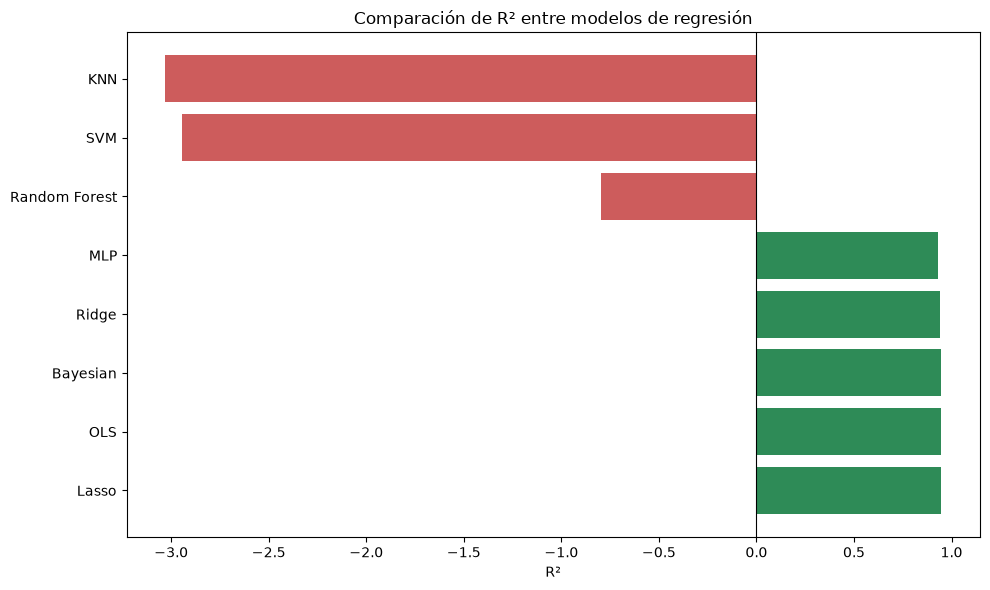

In [ ]:
plot.figure(figsize=(10, 6))
colores = ["seagreen" if r2 > 0 else "indianred" for r2 in df_resultados["R2"]]
plot.barh(df_resultados.index, df_resultados["R2"], color=colores)
plot.axvline(x=0, color="black", linewidth=0.8)
plot.xlabel("R2")
plot.title("Comparación de R2 entre modelos de regresión")
plot.tight_layout()
plot.savefig("../docs/comparacion_r2.png")
plot.show()

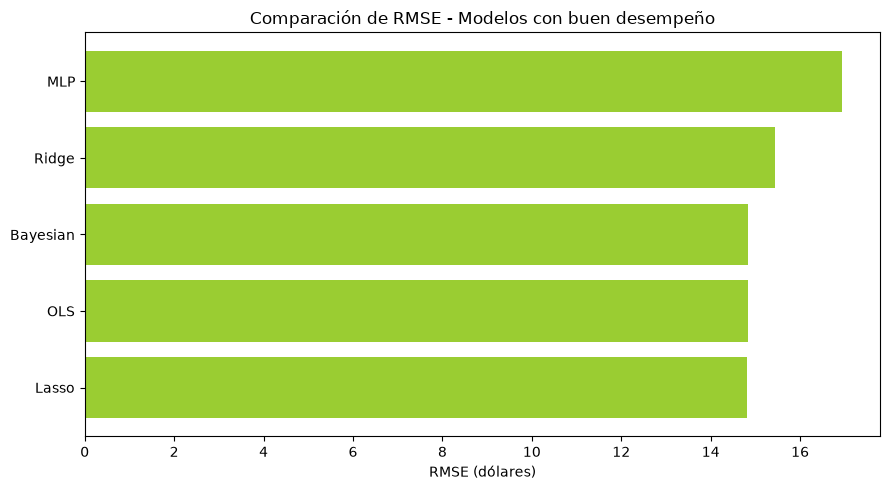

In [ ]:
modelos_buenos = ["OLS", "Ridge", "Lasso", "Bayesian", "MLP"]
df_buenos = df_resultados.loc[modelos_buenos].sort_values("RMSE")

plot.figure(figsize=(9, 5))
plot.barh(df_buenos.index, df_buenos["RMSE"], color="YellowGreen")
plot.xlabel("RMSE (dólares)")
plot.title("Comparación de RMSE - Modelos con buen desempeño")
plot.tight_layout()
plot.savefig("../docs/comparacion_rmse.png")
plot.show()

In [32]:
df_resultados = pd.DataFrame(resultados).T
df_resultados = df_resultados.sort_values("R2", ascending=False)
print(df_resultados)

                      MAE           MSE        RMSE        R2
Lasso           10.229389    219.098860   14.801988  0.947205
OLS             10.260060    219.865154   14.827851  0.947020
Bayesian        10.265056    219.978149   14.831660  0.946993
Ridge           10.852673    238.293306   15.436752  0.942580
MLP             11.930875    286.944341   16.939432  0.930856
Random Forest   66.982405   7451.107876   86.319800 -0.795456
SVM             87.402949  16378.934849  127.980213 -2.946749
KNN            114.438251  16722.035074  129.313708 -3.029424


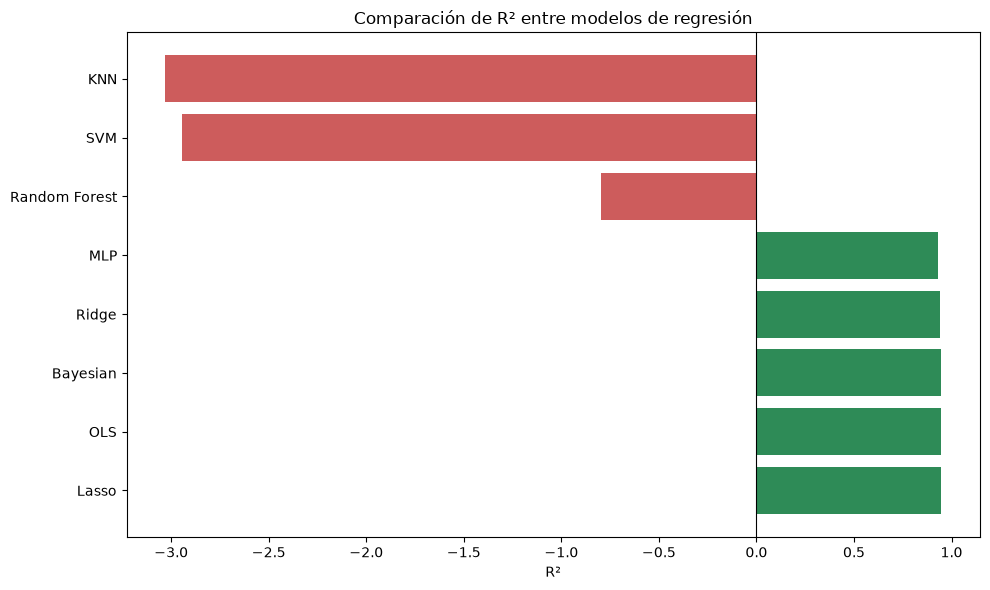

In [ ]:
plot.figure(figsize=(10, 6))
colores = ["seagreen" if r2 > 0 else "indianred" for r2 in df_resultados["R2"]]
plot.barh(df_resultados.index, df_resultados["R2"], color=colores)
plot.axvline(x=0, color="black", linewidth=0.8)
plot.xlabel("R2")
plot.title("Comparación de R2 entre modelos de regresión")
plot.tight_layout()
plot.savefig("../docs/comparacion_r2.png")
plot.show()

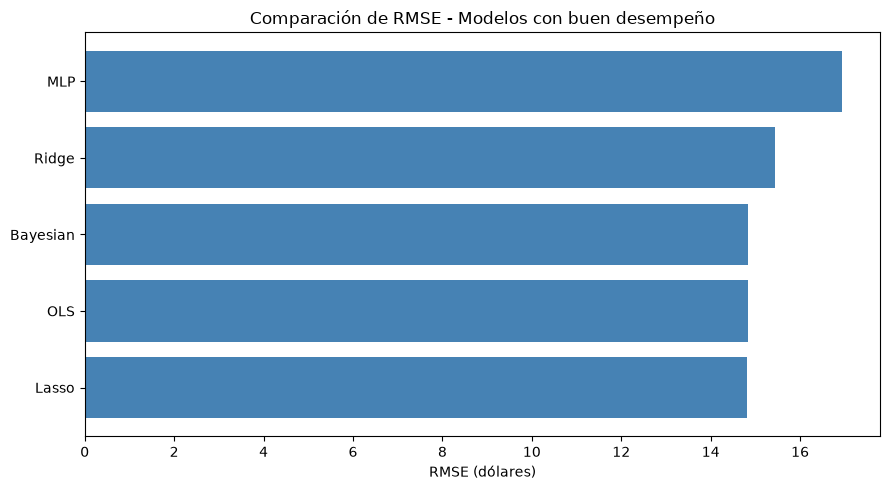

In [ ]:
modelos_buenos = ["OLS", "Ridge", "Lasso", "Bayesian", "MLP"]
df_buenos = df_resultados.loc[modelos_buenos].sort_values("RMSE")

plot.figure(figsize=(9, 5))
plot.barh(df_buenos.index, df_buenos["RMSE"], color="steelblue")
plot.xlabel("RMSE (dólares)")
plot.title("Comparación de RMSE - Modelos con buen desempeño")
plot.tight_layout()
plot.savefig("../docs/comparacion_rmse.png")
plot.show()

## Selección del Modelo Final

Con base en la comparación de las 4 métricas de evaluación, **Lasso Regression (α=0.01)**
fue seleccionado como el modelo con mejor capacidad predictiva para este problema.

De los 8 modelos evaluados, Lasso Regression obtuvo el mejor desempeño en las cuatro métricas simultáneamente (MAE=10.23, MSE=219.10, RMSE=14.80, R2=0.9472), seguido muy de cerca por OLS y Bayesian Ridge, con diferencias marginales entre los cuatro modelos lineales (Lasso, OLS, Bayesian Ridge, Ridge). Esto se explica por la naturaleza predominantemente lineal de la relación entre las variables predictoras —particularmente close y sma_7— y la variable objetivo, evidenciada desde el análisis exploratorio (correlación de 0.99-1.00).

La ventaja específica de Lasso frente a los demás modelos lineales radica en su capacidad de regularización L1, que eliminó automáticamente la variable volatility_7 del modelo (coeficiente reducido a 0), simplificando la solución sin sacrificar—de hecho, mejorando ligeramente—la capacidad predictiva.

En contraste, los modelos basados en distancia o particiones del espacio (KNN, Random Forest, SVM) presentaron un desempeño notablemente deficiente, con valores de R2 negativos, producto de una limitación estructural común: la incapacidad de extrapolar más allá del rango de precios observado en el conjunto de entrenamiento, en un activo (META) con tendencia alcista sostenida durante el periodo analizado. El modelo MLP, si bien logró un desempeño aceptable (R2=0.9309) al poder aproximar relaciones lineales dentro de su arquitectura, no logró superar a los modelos estrictamente lineales, reforzando la conclusión de que la complejidad adicional de estos modelos no aporta valor en un problema con una relación subyacente tan lineal como este.

Modelo final seleccionado: Lasso Regression (alpha=0.01)

In [94]:
import joblib

joblib.dump(lasso, "../models/modelo_final.pkl")
print("Modelo Lasso guardado en models/modelo_final.pkl")

Modelo Lasso guardado en models/modelo_final.pkl
